# Прогнозирование сердечного приступа

## Глава 1 Загрузка и описание данных

#### Прогнозирование вероятности сердечного приступа - задача классификации. Целевой признак (y-переменная) — "output", где 0 = низкая вероятность сердечного приступа, 1 = высокая вероятность сердечного приступа.

### Описание датасета:
- age: Возраст пациента
- sex: Пол пациента (1 = мужчина, 0 = женщина)
- exang: Стенокардия, вызванная физической нагрузкой (1 = да; 0 = нет)
- ca: Количество основных сосудов (0-3)
- cp: Тип боли в груди
    - Значение 1: типичная стенокардия
    - Значение 2: нетипичная стенокардия
    - Значение 3: неангинальная боль
    - Значение 4: бессимптомная
- trtbps: Артериальное давление в состоянии покоя (в мм рт. ст.)
- chol: Уровень холестерина (в мг/дл)
- fbs: Уровень сахара в крови натощак > 120 мг/дл (1 = true; 0 = false)
- restecg: Результаты электрокардиографии в состоянии покоя
    - Значение 0: норма
    - Значение 1: наличие аномалии ST-T (инверсия зубца T и/или подъём или депрессия сегмента ST > 0.05 мВ)
    - Значение 2: вероятная или определённая гипертрофия левого желудочка по критериям Эстеса
- thalachh: Максимальная достигнутая частота сердечных сокращений
- target: 0 = низкая вероятность сердечного приступа, 1 = высокая вероятность сердечного приступа 

## Глава 2 Предобработка данных

### В ходе предобработки данных:
- были удалены дубликаты, 
- удалили выбросы (данные лежащие за пределами 3х σ от среднего значения), 
- в ходе исследовательского анализа данных были изучены их распределения, а также удалены выбросы,
- построили матрицу корреляции и удалили некоррелирующие признаки,
- масштабировали данные с помощью StandardScaler,
- разделили выборку на трениоровочную и тестовую в соотношении 80/20

## Глава 3 Обучение моделей и их сравнение  

В проекте были выбраны 4 модели для обучения: 
- LogisticRegression (Логистическая регрессия). Логистическая регрессия — это метод классификации, который используется для предсказания вероятности принадлежности объекта к одному из двух классов. Она основана на использовании логистической функции (сигмоиды), которая преобразует линейную комбинацию признаков в значение вероятности.
- DecisionTreeClassifier (Дерево решений). Дерево решений — это алгоритм, который строит древовидную структуру для принятия решений. Каждый узел дерева представляет собой проверку условия на одном из признаков, а листья — итоговые классы.
- RandomForestClassifier (Случайный лес). Случайный лес — это ансамблевый метод, который строит множество деревьев решений и объединяет их предсказания (например, с помощью голосования) для получения более точного результата.
- CatBoostClassifier. CatBoost — это градиентный бустинг на деревьях решений, разработанный для работы с категориальными признаками без необходимости их предварительного кодирования. Он оптимизирован для высокой производительности и точности.


## Глава 4 Выводы

- В ходе исследования мы решили задачу классификации для прогнозирования вероятности сердечного приступа.
- Провели предобработку данных
- Обучили несколько моделей и сравнили их
- Выяснили, что для данной задачи лучшей оказалась - CatBoost.

In [463]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

In [464]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

In [465]:
RANDOM_STATE = 42

## 1 Загрузка данных

Смотрм на первые 5 строк выборки

In [466]:
data = pd.read_csv("/Users/admin/Desktop/Prognoz serdechnogo pristupa IKPI 22 Barkanov Chertkov/dataset.csv")

columns_eng = ['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output']
columns_rus = ['возраст', 'пол', 'боль_в_груди', 'давление', 'холестерин', 'глюкоза', 'кардиограмма', 'макс_ЧСС', 'физ_нагрузка', 'депрессия_ST', 'наклон_ST', 'кол-во_сосудов', 'талиум', 'приступ']
columns_rus_2 = ['боль_в_груди', 'кардиограмма', 'макс_ЧСС', 'физ_нагрузка', 'депрессия_ST', 'наклон_ST', 'кол-во_сосудов', 'талиум']

data.columns = columns_rus
display(data.head(), data.info())
data.columns = columns_eng

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   возраст         303 non-null    int64  
 1   пол             303 non-null    int64  
 2   боль_в_груди    303 non-null    int64  
 3   давление        303 non-null    int64  
 4   холестерин      303 non-null    int64  
 5   глюкоза         303 non-null    int64  
 6   кардиограмма    303 non-null    int64  
 7   макс_ЧСС        303 non-null    int64  
 8   физ_нагрузка    303 non-null    int64  
 9   депрессия_ST    303 non-null    float64
 10  наклон_ST       303 non-null    int64  
 11  кол-во_сосудов  303 non-null    int64  
 12  талиум          303 non-null    int64  
 13  приступ         303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,возраст,пол,боль_в_груди,давление,холестерин,глюкоза,кардиограмма,макс_ЧСС,физ_нагрузка,депрессия_ST,наклон_ST,кол-во_сосудов,талиум,приступ
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


None

без предобработки

In [467]:
X = data.drop("output", axis=1)
y = data["output"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
tree_predict = tree_model.predict(X_test)

random_model = RandomForestClassifier(n_estimators=20, random_state=42)
random_model.fit(X_train, y_train)
random_predict = random_model.predict(X_test)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_predict = log_model.predict(X_test)

catboost_model = CatBoostClassifier(verbose=0, depth=5, iterations=50, learning_rate=0.1)
catboost_model.fit(X_train, y_train)
catboost_predict = catboost_model.predict(X_test)

In [468]:
models_metrics = {
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression", "CatBoost"],
    "Accuracy": [
        accuracy_score(y_test, tree_predict),
        accuracy_score(y_test, random_predict),
        accuracy_score(y_test, log_predict),
        accuracy_score(y_test, catboost_predict)
    ],
    "Precision": [
        precision_score(y_test, tree_predict),
        precision_score(y_test, random_predict),
        precision_score(y_test, log_predict),
        precision_score(y_test, catboost_predict)
    ],
    "Recall": [
        recall_score(y_test, tree_predict),
        recall_score(y_test, random_predict),
        recall_score(y_test, log_predict),
        recall_score(y_test, catboost_predict)
    ]
}

metrics_df = pd.DataFrame(models_metrics)
metrics_df = metrics_df.round(2)
display(metrics_df)

,Model,Accuracy,Precision,Recall
0,Decision Tree,0.82,0.82,0.84
1,Random Forest,0.82,0.86,0.78
2,Logistic Regression,0.85,0.87,0.84
3,CatBoost,0.87,0.85,0.91


## 2 Предобработка данных

### Проверка на дубликаты

In [469]:
duplicate_rows = data[data.duplicated()]
print("Количество дубликатов: ", duplicate_rows.shape)
data = data.drop_duplicates()
duplicate_rows = data[data.duplicated()]
print("Удалили дубликаты. \nКоличество дубликатов после удаления: ", duplicate_rows.shape)

Количество дубликатов:  (1, 14)
Удалили дубликаты. 
Количество дубликатов после удаления:  (0, 14)


### Проверка типов данных

In [470]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trtbps    302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalachh  302 non-null    int64  
 8   exng      302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slp       302 non-null    int64  
 11  caa       302 non-null    int64  
 12  thall     302 non-null    int64  
 13  output    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


### Проверка на наличие пропусков

In [471]:
data.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

Пропусков в данных не обнаружено

### Базовый описательный анализ

Смотрим на средние значения признаков, среднее отклонение, минимальные и максимальные значения:

In [472]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trtbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalachh,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exng,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


### Считаем количество данных за пределами 3-х σ от среднего значения

In [473]:
mean = data.mean(axis=0)
std = data.std(axis=0)

outliers = (data[(data < (mean - 3 * std)) | (data > (mean + 3 * std))]).count()
print("Кол-во выбросов:\n", outliers)

Кол-во выбросов:
 age         0
sex         0
cp          0
trtbps      2
chol        4
fbs         0
restecg     0
thalachh    1
exng        0
oldpeak     2
slp         0
caa         4
thall       2
output      0
dtype: int64


### Удаляем такие данные

In [474]:
data = data[(data >= (mean - 3 * std)) & (data <= (mean + 3 * std))].dropna()
print("Размер выборки после удаления выбросов:\n", data.shape)

Размер выборки после удаления выбросов:
 (287, 14)


## Исследовательский анализ данных

## Распределение целевого признака "output"

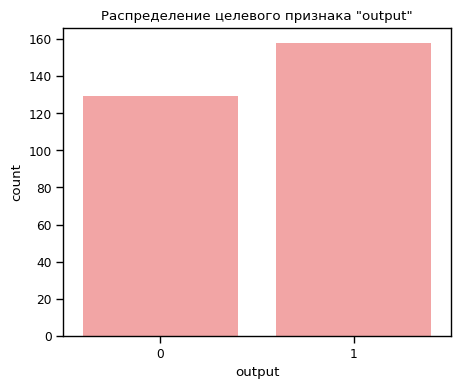

In [475]:
data["output"].value_counts(normalize=True)*100
plt.figure(figsize=(5,4))
plt.title('Распределение целевого признака "output"')
sns.countplot(x=data["output"], color="red", alpha=0.4);

Классы сбалансированы

## Анализ возраста

Минимальный возраст:  29
Средний возраст:  54.33449477351916
Максимальный возраст:  77


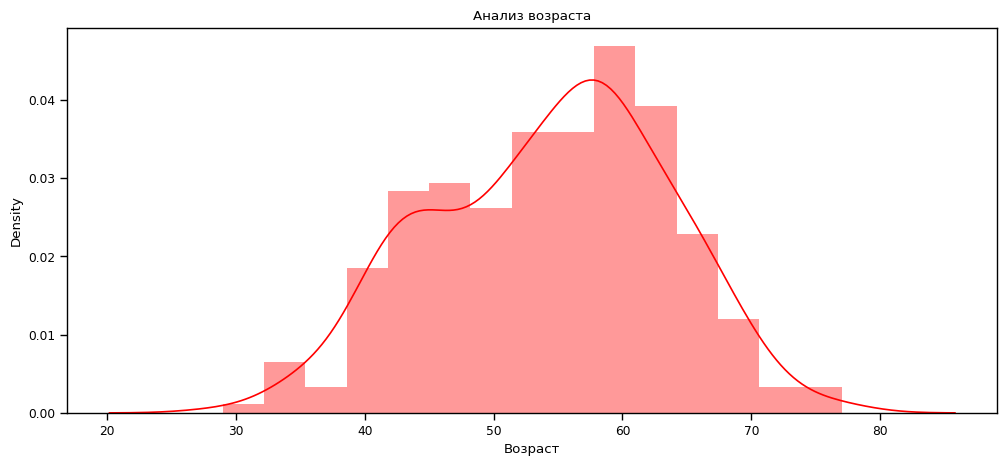

In [476]:
print("Минимальный возраст: ", data["age"].min())
print("Средний возраст: ", data["age"].mean())
print("Максимальный возраст: ", data["age"].max())
plt.figure(figsize=(12,5))
sns.distplot(x=data["age"], bins=15, color="red")
plt.title('Анализ возраста')
plt.xlabel('Возраст');

## Анализ холестерина

Максимальный уровень холестерина:  394.0


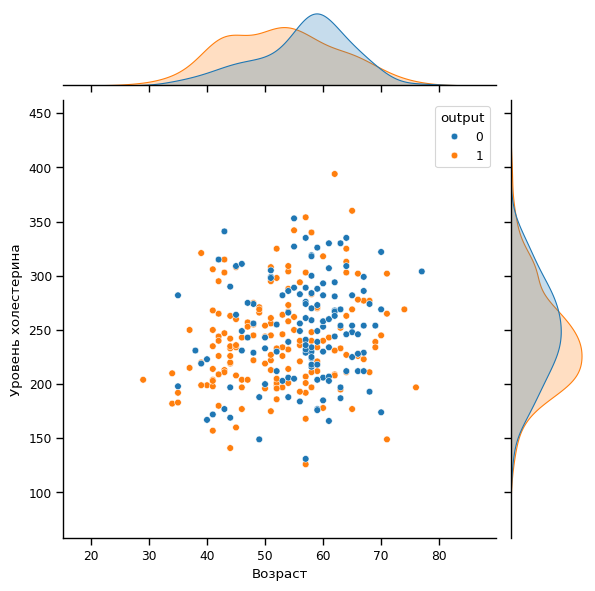

In [477]:
sns.jointplot(x="age", y="chol", data=data, hue="output")
plt.xlabel('Возраст')
plt.ylabel('Уровень холестерина')
print("Максимальный уровень холестерина: ", data["chol"].max());

Удаляем выбросы в холистерине

In [478]:
data = data[data["chol"] < 380]
print("Максимальный уровень холестерина после удаления выбросов: ", data["chol"].max())

Максимальный уровень холестерина после удаления выбросов:  360.0


## Анализ пола

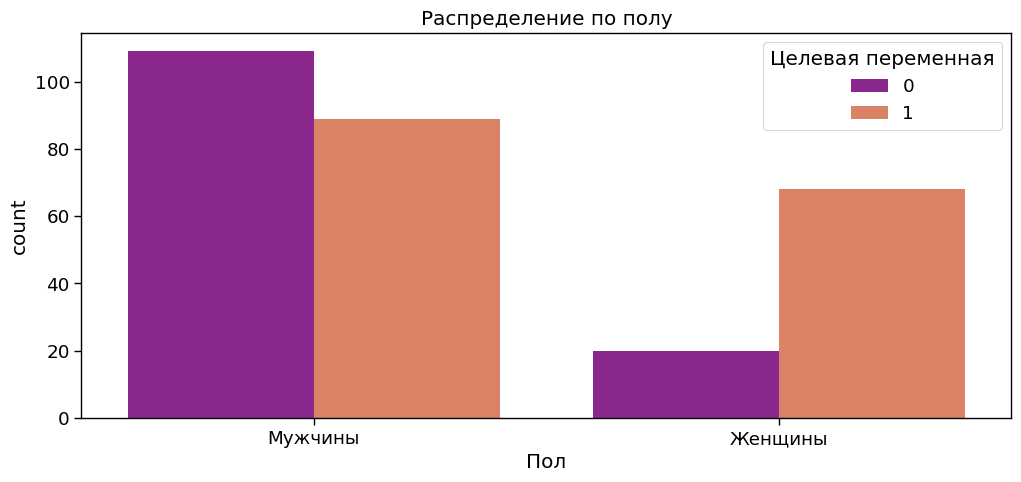

In [479]:
tempd = data.copy()
tempd["sex"] = data["sex"].replace({0: "Женщины", 1: "Мужчины"})
tempd["sex"].value_counts(normalize=True)*100
plt.figure(figsize=(12,5))
sns.set_context("paper", font_scale=1.5)
sns.countplot(x="sex", palette="plasma", data=tempd, hue="output")
plt.xlabel('Пол')
plt.title("Распределение по полу")
plt.legend(title="Целевая переменная");

Вероятность сердечного приступа в зависимости от пола:

In [480]:
gender_gb = data.groupby("output")["sex"]
gender_gb.value_counts()

output  sex
0       1      109
        0       20
1       1       89
        0       68
Name: count, dtype: int64

## Анализ типов боли в груди

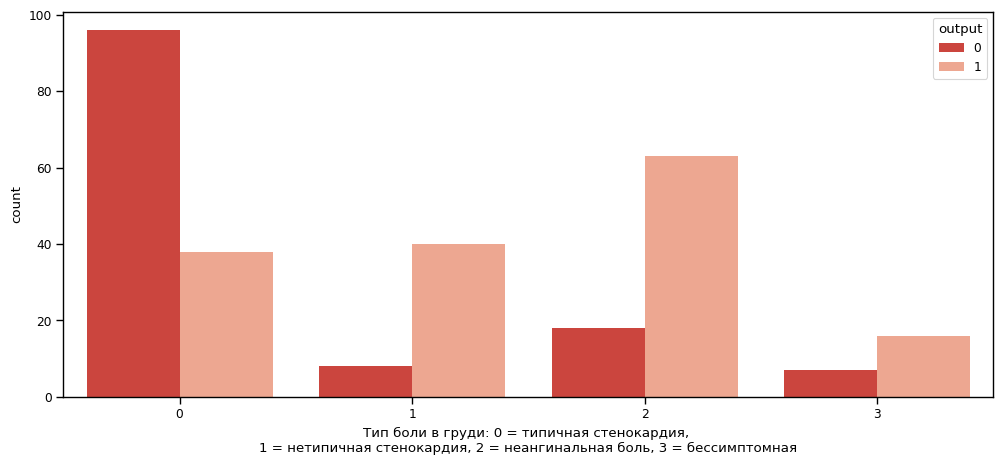

In [481]:
plt.figure(figsize=(12,5))
sns.set_context("paper", font_scale=1)
sns.countplot(x="cp", palette="Reds_r", data=data, hue="output")
plt.xlabel("Тип боли в груди: 0 = типичная стенокардия, \n1 = нетипичная стенокардия, 2 = неангинальная боль, 3 = бессимптомная");

Типичная стенокардия (0) чаще встречается у пациентов с низкой вероятностью сердечного приступа, тогда как бессимптомные пациенты (3) и другие виды боли могут быть более связаны с высоким риском.

## Анализ артериального давления

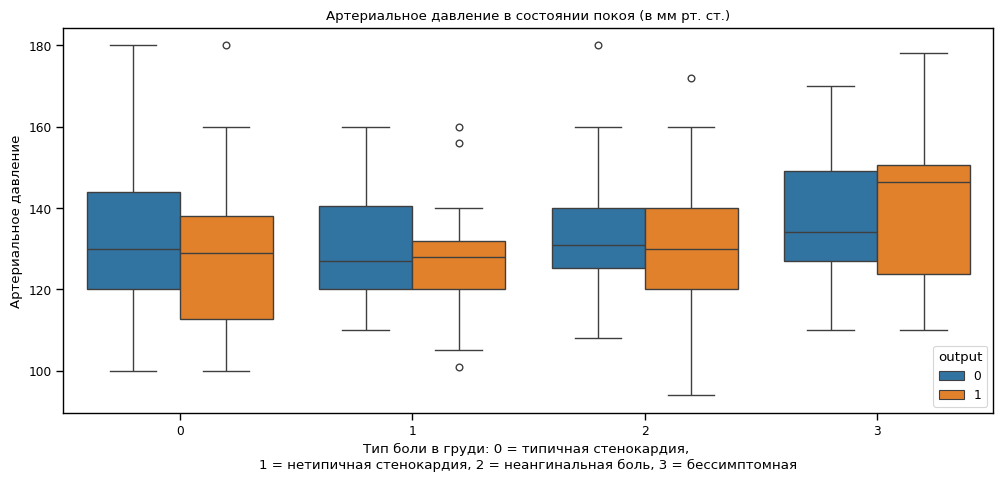

In [482]:
plt.figure(figsize=(12,5))
sns.boxplot(x="cp", y="trtbps", data=data, hue="output")
plt.title('Артериальное давление в состоянии покоя (в мм рт. ст.)')
plt.xlabel("Тип боли в груди: 0 = типичная стенокардия, \n1 = нетипичная стенокардия, 2 = неангинальная боль, 3 = бессимптомная")
plt.ylabel("Артериальное давление");

У пациентов с бессимптомным течением (тип 3) артериальное давление в среднем выше, чем у других групп

Удалили выбросы в артериальном давлении

In [483]:
data = data[data["trtbps"] < 180]
print("Максимальное артериальное давление после удаления выбросов: ", data["trtbps"].max())

Максимальное артериальное давление после удаления выбросов:  178.0


## Анализ максимальной частоты сердечных сокращений

Минимальная частота сердечных сокращений после удаления выбросов:  103.0


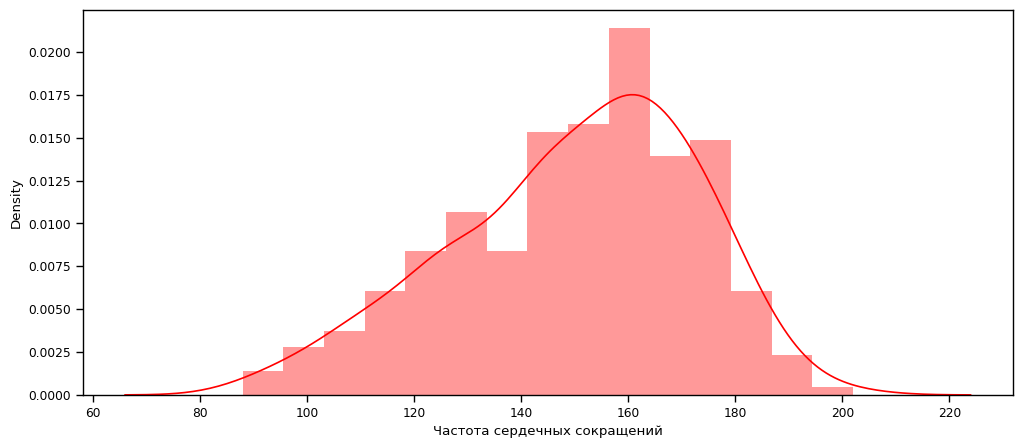

In [484]:
plt.figure(figsize=(12,5))
sns.distplot(x=data["thalachh"], bins=15, color="red")
plt.xlabel('Частота сердечных сокращений')
data = data[data["thalachh"] > 100]
print("Минимальная частота сердечных сокращений после удаления выбросов: ", data["thalachh"].min());

## Анализ уровня сахара в крови

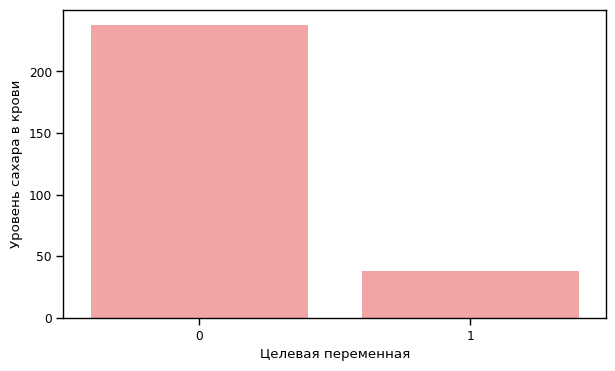

In [485]:
data["fbs"].value_counts(normalize=True)*100
plt.figure(figsize=(7,4))
sns.countplot(x=data["fbs"], color="red", alpha=0.4)
plt.ylabel('Уровень сахара в крови')
plt.xlabel('Целевая переменная');

## Анализ результатов ЭКГ

In [486]:
data["restecg"].value_counts(normalize=True)*100
ekg_normal = len(data[data["restecg"] == 0])/len(data["restecg"])*100
ekg1 = len(data[data["restecg"] == 1])/len(data["restecg"])*100
ekg2 = len(data[data["restecg"] == 2])/len(data["restecg"])*100

print("Аномальная ЭКГ: {:.2f}%".format(ekg1))
print("Гипертрофия по Эстесу: {:.2f}%".format(ekg2))
print("Нормальная ЭКГ: {:.2f}%".format(ekg_normal))

Аномальная ЭКГ: 50.36%
Гипертрофия по Эстесу: 1.09%
Нормальная ЭКГ: 48.55%


## Корреляционный анализ

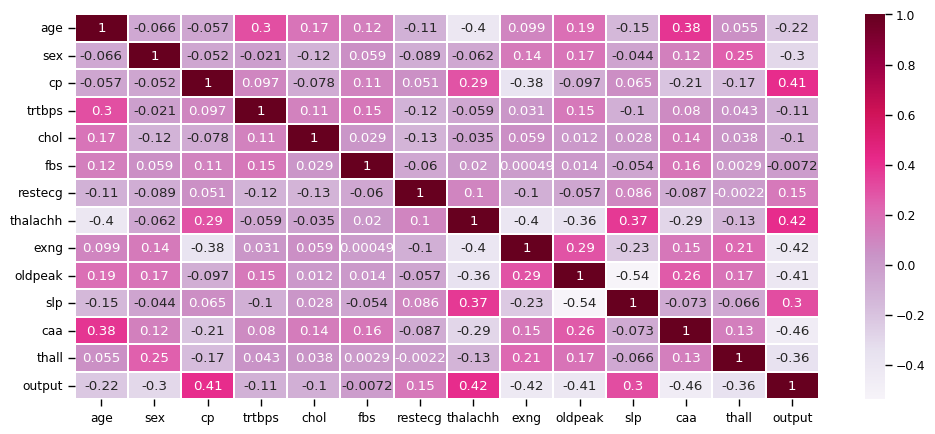

In [487]:
data.corr()["output"].sort_values(ascending=False)
plt.figure(figsize=(12,5))
sns.heatmap(data.corr(method="pearson"), cmap="PuRd", annot=True, lw=0.1);

#### Удаляем некоррелирующие и незначимые признаки

In [488]:
data = data.drop(["trtbps", "chol", "fbs", "age", "sex"], axis=1)

#### Оставшиеся признаки:

In [489]:
data_t = data.copy()
data_t.columns = columns_rus_2 + ['приступ']
data_t.info()

<class 'pandas.core.frame.DataFrame'>
Index: 276 entries, 0 to 302
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   боль_в_груди    276 non-null    int64  
 1   кардиограмма    276 non-null    int64  
 2   макс_ЧСС        276 non-null    float64
 3   физ_нагрузка    276 non-null    int64  
 4   депрессия_ST    276 non-null    float64
 5   наклон_ST       276 non-null    int64  
 6   кол-во_сосудов  276 non-null    float64
 7   талиум          276 non-null    float64
 8   приступ         276 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 21.6 KB


### Подготовка данных для обучения моделей

Разбиваем предобработанные данные на тренировочную и тестовую выборки

In [490]:
X = data.drop("output", axis=1)
y = data["output"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Масштабируем данные

In [491]:
scaler = StandardScaler()

X_train_original = X_train.copy()
X_test_original = X_test.copy()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4 Обучение моделей

## Модель: Дерево решений

Обучаем модель DecisionTreeClassifier на тренировочной выборке, далее делаем прогноз на тестовой выборке и оцениваем ее качество на метриках

In [492]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
tree_predict = tree_model.predict(X_test)

## Модель: Случайный лес

Обучаем модель RandomForestClassifier на тренировочной выборке, далее делаем прогноз на тестовой выборке и оцениваем ее качество на метриках

In [493]:
random_model = RandomForestClassifier(n_estimators=20, random_state=42)
random_model.fit(X_train, y_train)
random_predict = random_model.predict(X_test)

## Модель: Логистическая регрессия

Обучаем модель LogisticRegression на тренировочной выборке, далее делаем прогноз на тестовой выборке и оцениваем ее качество на метриках

In [494]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_predict = log_model.predict(X_test)

## Модель: CatBoost

Обучаем модель CatBoostClassifier на тренировочной выборке, далее делаем прогноз на тестовой выборке и оцениваем ее качество на метриках

In [495]:
catboost_model = CatBoostClassifier(verbose=0, depth=5, iterations=50, learning_rate=0.1)
catboost_model.fit(X_train, y_train)
catboost_predict = catboost_model.predict(X_test)

### Итоговое сравнение моделей:

In [496]:
models_metrics = {
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression", "CatBoost"],
    "Accuracy": [
        accuracy_score(y_test, tree_predict),
        accuracy_score(y_test, random_predict),
        accuracy_score(y_test, log_predict),
        accuracy_score(y_test, catboost_predict)
    ],
    "Precision": [
        precision_score(y_test, tree_predict),
        precision_score(y_test, random_predict),
        precision_score(y_test, log_predict),
        precision_score(y_test, catboost_predict)
    ],
    "Recall": [
        recall_score(y_test, tree_predict),
        recall_score(y_test, random_predict),
        recall_score(y_test, log_predict),
        recall_score(y_test, catboost_predict)
    ]
}

metrics_df = pd.DataFrame(models_metrics)
metrics_df = metrics_df.round(2)
display(metrics_df)

,Model,Accuracy,Precision,Recall
0,Decision Tree,0.84,1.00,0.74
1,Random Forest,0.86,0.91,0.85
2,Logistic Regression,0.82,0.85,0.85
3,CatBoost,0.89,0.91,0.91


Лучшей моделью оказалась CatBoostClassifier со значением метрик: 
- Точность модели: 89.29%
- precision: 0.91, 
- recall: 0.91

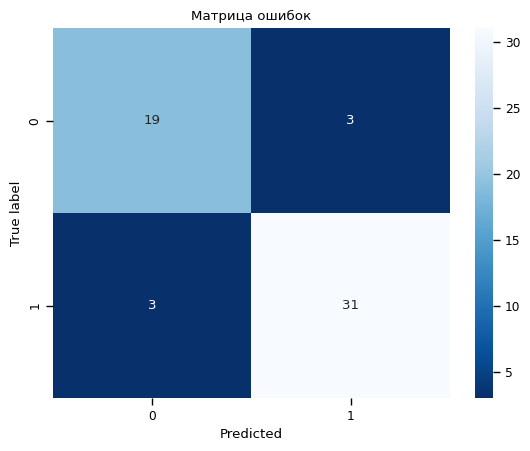

In [497]:
cm = confusion_matrix(y_test, catboost_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.title('Матрица ошибок')
plt.ylabel('True label')
plt.xlabel('Predicted');

Ошибки могут возникать из-за дисбаланса классов, маленького размера обучающей выборки, а также небольшого различия в значениях параметров некоторых здоровых и не здоровых пациентов.

## Вывод
В ходе работы:
1.	Проведена предобработка - удалены дубликаты и выбросы, устранены потенциально нерелевантные признаки, а также выполнено масштабирование данных для обеспечения равномерного вклада признаков в обучение моделей. 
2.	Проведен исследовательский анализ, в рамках которого удалось выявить статистические закономерности и различия между группами с высокой и низкой вероятностью сердечного приступа.
3.	Обучены модели машинного обучения – LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, CatBoostClassifier
4.	Сравнили результаты классификации моделей с помощью метрик accuracy_score, precision_score, recall_score, confusion_matrix, выбрана модель с наилучшим качеством
